# Variational Autoencoders (VAE)

A Variational Autoencoder (VAE) is a powerful generative deep learning model designed to map complex data, such as images or text, into a continuous, lower-dimensional latent space and generate entirely new variations of that data

We build develop VAE using **PyTorch** and test it on the **MNIST** dataset of handwritten digits.

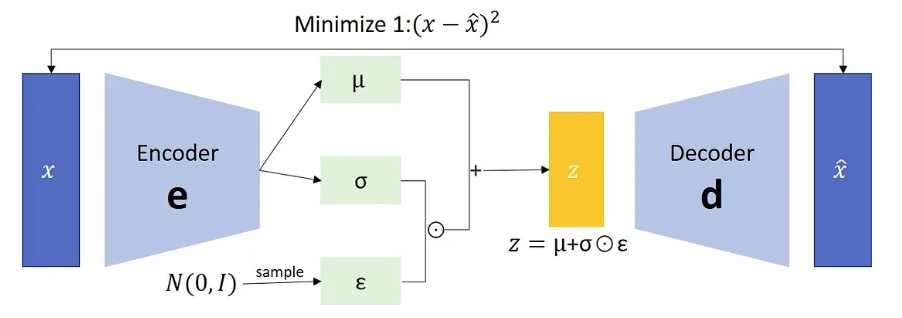

## 1. Environment setup

We rely on a small, standard scientific Python stack. `torch` and `torch.nn` provide the neural-network building blocks, `torchvision` gives us the MNIST dataset, and `matplotlib` is used for every figure. We also fix the random seed so that the results are reproducible from one run to the next.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Reproducibility: fix the seeds so every run gives the same figures.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use a GPU if one happens to be available, otherwise the CPU is perfectly fine here.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Using device   :", device)

PyTorch version: 2.11.0+cpu
Using device   : cpu


## 2. The MNIST dataset

Before modelling anything, we need to understand our data.

**MNIST** (Modified National Institute of Standards and Technology database) is one of the the most widely used benchmark in machine learning. It consists of **70,000 grayscale images of handwritten digits** (0 through 9), split into **60,000 training images** and **10,000 test images**. Each image is **28 x 28 pixels**, so a single image is a grid of 784 numbers. Every pixel is an intensity value that we scale to lie between 0 (black background) and 1 (white ink).

In [2]:
# ToTensor() loads each image as a float tensor with values already scaled to [0, 1].
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Training images:", len(train_dataset))
print("Test images    :", len(test_dataset))

img, label = train_dataset[0]
print("Single image shape:", tuple(img.shape), "(channels, height, width)")
print("Pixel value range :", float(img.min()), "to", float(img.max()))

100%|██████████| 9.91M/9.91M [00:00<00:00, 143MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 52.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 79.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 688kB/s]


Training images: 60000
Test images    : 10000
Single image shape: (1, 28, 28) (channels, height, width)
Pixel value range : 0.0 to 1.0


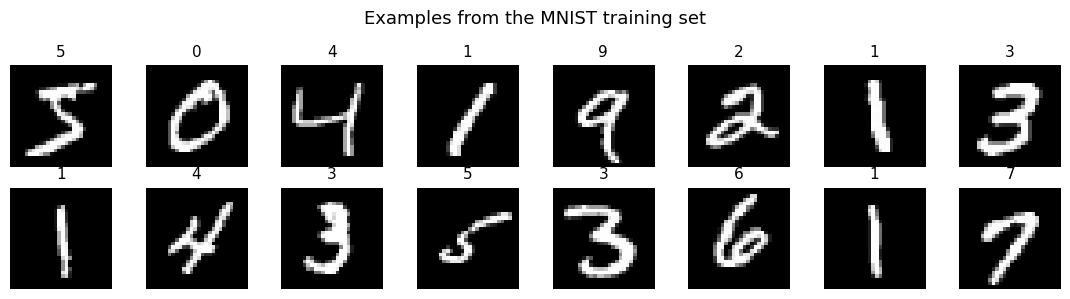

In [3]:
# A quick look at a handful of digits and their labels.
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, idx in zip(axes.ravel(), range(16)):
    image, y = train_dataset[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(str(y), fontsize=11)
    ax.axis("off")
fig.suptitle("Examples from the MNIST training set", fontsize=13)
plt.tight_layout()
plt.show()

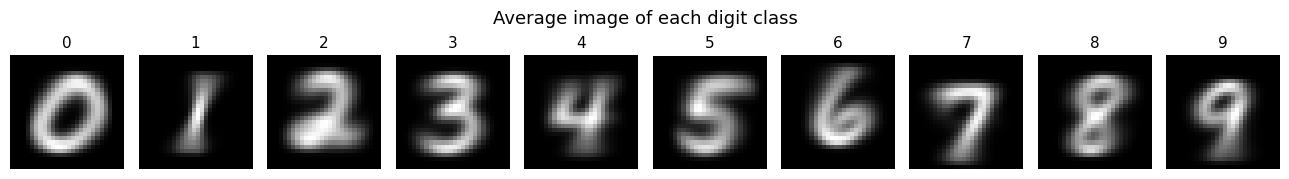

In [4]:
# The "average digit" for each class. These blurry means are essentially what a
# very simple model would predict; a good generative model must do far better.
labels_all = train_dataset.targets.numpy()
images_all = train_dataset.data.numpy().astype("float32") / 255.0

fig, axes = plt.subplots(1, 10, figsize=(13, 1.8))
for digit in range(10):
    mean_image = images_all[labels_all == digit].mean(axis=0)
    axes[digit].imshow(mean_image, cmap="gray")
    axes[digit].set_title(str(digit), fontsize=11)
    axes[digit].axis("off")
fig.suptitle("Average image of each digit class", fontsize=13)
plt.tight_layout()
plt.show()

## 3. From Autoencoders to Variational Autoencoders

### 3.1 The Autoencoder

An **autoencoder (AE)** is a neural network that learns to reconstruct its input. It consists of two main components:

- an **encoder** $f$, which compresses an input image $x$ into a lower-dimensional vector $z$, called the **latent representation**;
- a **decoder** $g$, which reconstructs the input from the latent representation, producing $\hat{x}=g(z)$.

The latent representation acts as a **bottleneck**, forcing the network to retain only the most important information about the input instead of memorizing every pixel. During training, the network minimizes a **reconstruction loss**, such as the mean squared error:

$$
\mathcal{L}_{\text{AE}} = \|x - g(f(x))\|^2.
$$

### 3.2 Why a Standard Autoencoder Cannot Generate New Samples

Although an autoencoder learns a compact latent representation, it is **not** a good generative model. The encoder maps each training sample to an arbitrary location in the latent space without imposing any particular structure. As a result, many regions of the latent space contain no meaningful representations. If a random latent vector is sampled from one of these regions, the decoder typically produces unrealistic or meaningless outputs.

### 3.3 The Main Idea of the Variational Autoencoder

The **Variational Autoencoder (VAE)**, introduced by **Kingma and Welling (2013)**, addresses this limitation by modifying the latent representation in two ways:

1. Instead of mapping an input to a **single latent vector**, the encoder predicts a **Gaussian distribution** for each input, characterized by its mean $\mu$ and variance $\sigma^2$.
2. During training, an additional regularization term encourages these latent distributions to remain close to a **standard normal distribution** $\mathcal{N}(0, I)$.

As a result, the latent space becomes **continuous, smooth, and well-structured**, allowing new samples to be generated by simply drawing

$$
z \sim \mathcal{N}(0, I)
$$

and passing it through the decoder.

### The variational autoencoder at a glance

The figure below illustrates the complete VAE pipeline for a single input sample. An input $x$ is passed through the encoder network $\text{Model}_{\phi}$, which is **deterministic** and predicts the parameters $\mu$ and $\sigma$ of a Gaussian distribution over the latent space. A noise sample $\epsilon$ is then drawn from the fixed distribution $p(\epsilon)=\mathcal{N}(0,I)$ and combined with $\mu$ and $\sigma$ to obtain the latent representation $z$ through the **reparameterization trick**. The decoder network $\text{Model}_{\theta}$, which is also deterministic, maps $z$ to a reconstructed output $y$. In probabilistic terms, the encoder models the approximate posterior $q_{\phi}(z \mid x)$, while the decoder models the conditional likelihood $p_{\theta}(x \mid z)$.

<div style="text-align:center">
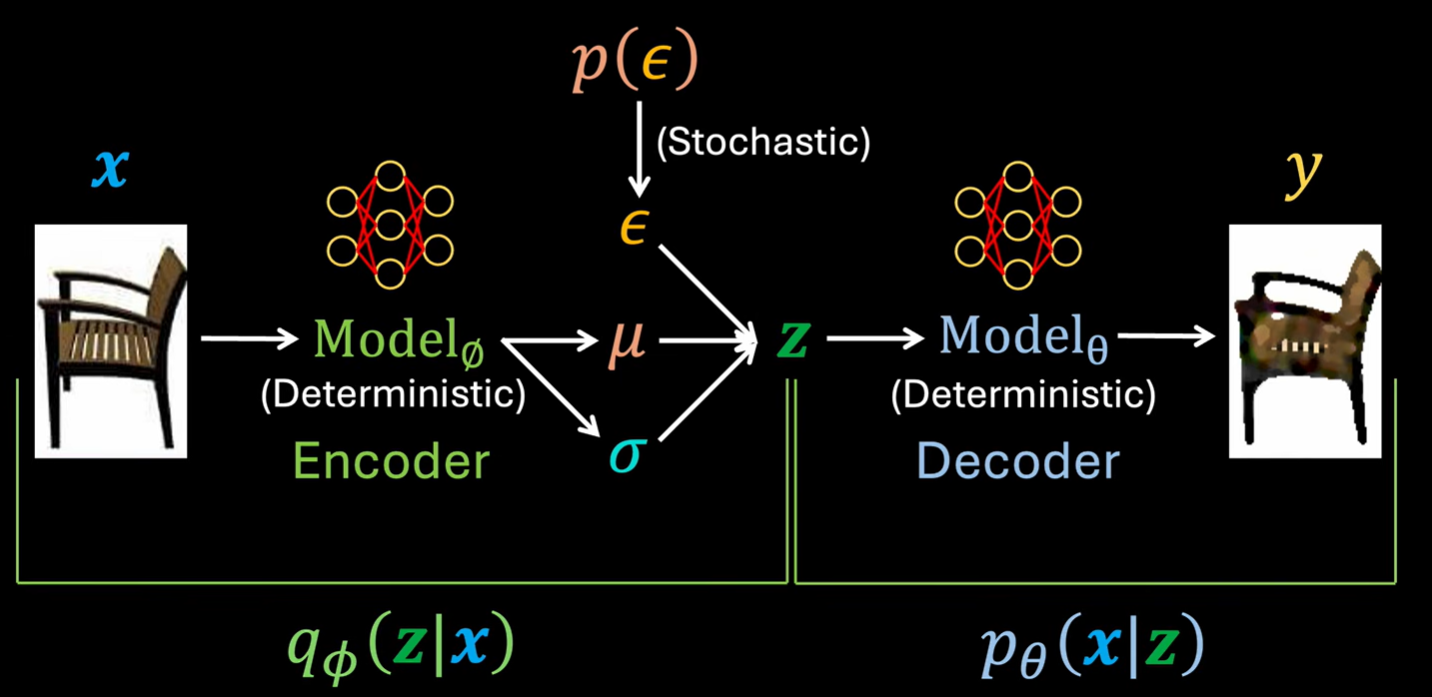
</div>

<div style="text-align:center"><em>Figure: schematic of a variational autoencoder, shown here on an image of a chair. The encoder maps the input to a distribution, a latent code is sampled from it, and the decoder reconstructs the input.</em></div>

## 4. The probabilistic model and the mathematics



### 4.1 A latent-variable model

We assume each image $x$ is produced in two steps. First, nature draws a hidden (**latent**) vector $z$ from a simple **prior** distribution, which we choose to be a standard normal:

$$
p(z) = \mathcal{N}(z \mid 0, I).
$$

Second, a decoder network with parameters $\theta$ turns that $z$ into an image through a distribution $p_\theta(x \mid z)$. Our goal is to make the model assign high probability to real images. The probability the model assigns to an image is obtained by averaging over all possible latent causes:

$$
p_\theta(x) = \int p_\theta(x \mid z)\, p(z)\, dz .
$$

This integral is **intractable**: we cannot compute it for a neural-network decoder because it sums over every possible $z$. This is the central difficulty the VAE is designed to sidestep.

### 4.2 The encoder as an approximate posterior

Ideally we would like to know, for a given image $x$, which latent codes could have produced it. That is the **posterior** $p_\theta(z \mid x)$, and it is also intractable. The VAE's trick is to **approximate** it with a second network, the **encoder** with parameters $\phi$, which outputs a Gaussian:

$$
q_\phi(z \mid x) = \mathcal{N}\!\big(z \mid \mu_\phi(x),\; \operatorname{diag}(\sigma_\phi^2(x))\big).
$$

In words: given an image, the encoder predicts a mean vector $\mu_\phi(x)$ and a (diagonal) variance $\sigma_\phi^2(x)$. The latent code for that image is then somewhere in the cloud described by this Gaussian, rather than a single fixed point.

### 4.3 The evidence lower bound (ELBO)

Because $\log p_\theta(x)$ is intractable, we optimize a tractable **lower bound** on it instead. Using Jensen's inequality one can show, for any image $x$,

$$
\log p_\theta(x) \;\ge\; \underbrace{\mathbb{E}_{q_\phi(z\mid x)}\big[\log p_\theta(x \mid z)\big]}_{\text{reconstruction term}} \;-\; \underbrace{D_{\mathrm{KL}}\!\big(q_\phi(z \mid x)\,\|\,p(z)\big)}_{\text{regularization term}} \;=\; \mathcal{L}(\theta, \phi; x).
$$

The right-hand side $\mathcal{L}$ is the **Evidence Lower BOund**, or **ELBO**. Maximizing it pushes up a lower bound on the true log-probability of the data, which is exactly what we want. The ELBO has two intuitive parts:

- The **reconstruction term** $\mathbb{E}_{q_\phi(z\mid x)}[\log p_\theta(x \mid z)]$ is large when latent codes drawn from the encoder can be decoded back into the original image. It rewards *accuracy*.
- The **KL divergence** term $D_{\mathrm{KL}}(q_\phi(z\mid x)\,\|\,p(z))$ measures how far the encoder's Gaussian is from the standard-normal prior. Subtracting it *regularizes* the latent space, pulling every image's distribution toward $\mathcal{N}(0, I)$ so the space stays smooth and gap-free. It rewards *organization*.

Training maximizes the ELBO, or equivalently **minimizes** its negative, which is the loss we will code up.

### 4.4 The KL term has a closed form

Because both $q_\phi(z\mid x)$ and $p(z)$ are Gaussians, the KL divergence can be written down exactly, with no integral to approximate. For a latent space of dimension $J$, and writing the encoder output for one image as means $\mu_j$ and variances $\sigma_j^2$,

$$
D_{\mathrm{KL}}\big(q_\phi(z\mid x)\,\|\,\mathcal{N}(0, I)\big)
= -\frac{1}{2} \sum_{j=1}^{J} \Big( 1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2 \Big).
$$

This clean formula is one reason Gaussians are chosen. In code we let the network predict $\log \sigma_j^2$ (called the *log-variance*) rather than $\sigma_j^2$ directly, which keeps the numbers numerically stable and automatically guarantees a positive variance.

## 5. The reparameterization trick

There is one obstacle left. To evaluate the reconstruction term we must **sample** $z$ from $q_\phi(z\mid x)$. But sampling is a random operation, and we cannot back-propagate gradients through a random draw. Without gradients flowing back into $\mu_\phi$ and $\sigma_\phi$, the encoder cannot learn.

The **reparameterization trick** solves this by moving the randomness out of the way. Instead of drawing $z$ directly from $\mathcal{N}(\mu, \sigma^2)$, we draw a noise variable $\epsilon$ from a *fixed* standard normal and then rescale and shift it:

$$
\epsilon \sim \mathcal{N}(0, I), \qquad z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon,
$$

where $\odot$ is element-wise multiplication. The value $z$ still follows the desired Gaussian, but now the only random part, $\epsilon$, does not depend on the network parameters. The path from $\mu$ and $\sigma$ to $z$ is a plain arithmetic expression, so gradients flow straight through it.

## 6. The loss function

Putting the pieces together, we **minimize the negative ELBO**, averaged over the training images. For a single image it is:

$$
\mathcal{L}(\theta, \phi; x) \;=\; \underbrace{-\,\mathbb{E}_{q_\phi(z\mid x)}\big[\log p_\theta(x\mid z)\big]}_{\text{reconstruction loss}} \;+\; \underbrace{D_{\mathrm{KL}}\!\big(q_\phi(z\mid x)\,\|\,p(z)\big)}_{\text{KL loss}} .
$$

**Reconstruction loss.** Because MNIST pixels lie in $[0, 1]$, we treat each pixel as the probability of an independent Bernoulli variable and use the **binary cross-entropy** between the input $x$ and the decoder output $\hat{x}$, summed over all 784 pixels:

$$
-\log p_\theta(x \mid z) \;=\; -\sum_{i=1}^{784} \Big[ x_i \log \hat{x}_i + (1 - x_i)\log(1 - \hat{x}_i) \Big].
$$

**KL loss.** We use the closed-form Gaussian expression derived in Section 4.4.

The two terms pull in opposite directions, and their balance is what makes a VAE work. The reconstruction term wants each image to be encoded precisely; the KL term wants every encoding to look like standard-normal noise. The compromise they reach is a latent space that is both *informative* (you can still tell the digits apart) and *smooth* (you can sample from it and interpolate through it).

## The training algorithm in pseudocode

Before writing any PyTorch, it helps to see the whole training procedure laid out as a single algorithm. The pseudocode below is written entirely in the notation of this notebook, so every line has a direct counterpart in the code that follows. The encoder $\text{Encoder}_\phi$ predicts the mean $\mu$ and the log-variance $\log \sigma^2$; the decoder $\text{Decoder}_\theta$ turns a latent code $z$ back into an image $\hat{x}$. The two losses are the pixel-wise binary cross-entropy $\mathcal{L}_{\text{recon}}$ and the Gaussian KL divergence $\mathcal{L}_{\text{KL}}$ from Sections 4 to 6.

```text
Algorithm: Training a Variational Autoencoder   (this is exactly what Sections 7-8 implement)

Input : training set D; encoder Encoder_phi; decoder Decoder_theta;
        learning rate eta = 1e-3; number of epochs E = 15; batch size B = 128
Output: trained parameters phi (encoder) and theta (decoder)

 1:  initialize phi and theta                                    # random initial weights
 2:  for epoch = 1 to E do
 3:      for each mini-batch {x_1, ..., x_B} drawn from D do
 4:          for each example x in the mini-batch do             # the network does this in parallel
 5:              (mu, log s^2)  <-  Encoder_phi(x)                # encode: predict the latent Gaussian
 6:              s              <-  exp( 1/2 * log s^2 )          # standard deviation from log-variance
 7:              eps            ~   N(0, I)                       # draw ONE fresh noise sample
 8:              z              <-  mu + s (*) eps                # reparameterization trick (Section 5)
 9:              x_hat          <-  Decoder_theta(z)             # decode to a reconstruction in [0, 1]
10:              L_recon(x)     <-  - SUM_i [ x_i log x_hat_i + (1 - x_i) log(1 - x_hat_i) ]   # BCE over 784 pixels
11:              L_KL(x)        <-  - 1/2 SUM_j ( 1 + log s^2_j - mu_j^2 - s^2_j )             # KL from N(0, I)
12:              L(x)           <-  L_recon(x) + L_KL(x)          # per-example negative ELBO (Section 6)
13:          end for
14:          L_batch  <-  SUM_{x in batch} L(x)                  # total loss over the mini-batch
15:          (g_phi, g_theta)  <-  grad_{phi, theta} L_batch     # backpropagation  ->  loss.backward()
16:          (phi, theta)      <-  Adam-update( (phi, theta), (g_phi, g_theta), eta )   # optimizer.step()
17:      end for
18:  end for
19:  return phi, theta
```

Here `(*)` denotes element-wise multiplication. A few points worth noting, since the notation in other textbooks and slides often differs from ours:



## 7. Implementation in PyTorch

Our network is deliberately small and fully connected so the mathematics stays visible. The encoder maps the 784 input pixels through one hidden layer of 400 units and then splits into two heads: one predicting the mean $\mu$ and one predicting the log-variance $\log\sigma^2$. The decoder mirrors this, mapping the latent vector back up to 784 pixels and squashing them into $[0, 1]$ with a sigmoid.

We deliberately choose a **2-dimensional latent space**. Two dimensions are enough to learn recognizable digits, and, crucially, they let us **plot the entire latent space on a flat page** later on. A larger latent space (for example 20 dimensions) would give sharper reconstructions but could not be visualized so directly.

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: shared hidden layer, then two separate heads.
        self.fc1      = nn.Linear(input_dim, hidden_dim)
        self.fc_mu    = nn.Linear(hidden_dim, latent_dim)      # predicts the mean
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)     # predicts log(variance)

        # Decoder: latent vector back up to a full image.
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # z = mu + sigma * eps, with eps ~ N(0, I). This is the trick from Section 5.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))     # output pixels in [0, 1]

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


model = VAE(latent_dim=2).to(device)
print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
)


In [6]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction term: Bernoulli negative log-likelihood, summed over pixels.
    recon = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction="sum")
    # KL term: closed-form divergence from N(0, I), summed over latent dimensions.
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl

## 8. Training

We train with the Adam optimizer for a modest number of epochs. On each mini-batch we run the images through the model, compute the negative ELBO, and update both the encoder and the decoder together. We track the three quantities separately, the total loss and its reconstruction and KL parts, so that we can watch the trade-off between accuracy and regularization play out during training.

In [7]:
batch_size = 128
epochs     = 15
lr         = 1e-3

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

history = {"loss": [], "recon": [], "kl": []}

for epoch in range(1, epochs + 1):
    model.train()
    running = {"loss": 0.0, "recon": 0.0, "kl": 0.0}

    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(images)
        loss, recon_term, kl_term = vae_loss(recon, images, mu, logvar)
        loss.backward()
        optimizer.step()

        running["loss"]  += loss.item()
        running["recon"] += recon_term.item()
        running["kl"]    += kl_term.item()

    # Report the average loss per image for this epoch.
    n = len(train_loader.dataset)
    for key in history:
        history[key].append(running[key] / n)

    print(f"Epoch {epoch:2d}/{epochs} | "
          f"ELBO loss {history['loss'][-1]:7.2f} | "
          f"reconstruction {history['recon'][-1]:7.2f} | "
          f"KL {history['kl'][-1]:6.2f}")

Epoch  1/15 | ELBO loss  190.94 | reconstruction  185.21 | KL   5.73
Epoch  2/15 | ELBO loss  168.88 | reconstruction  163.87 | KL   5.00
Epoch  3/15 | ELBO loss  164.26 | reconstruction  159.11 | KL   5.15
Epoch  4/15 | ELBO loss  161.92 | reconstruction  156.67 | KL   5.25
Epoch  5/15 | ELBO loss  160.24 | reconstruction  154.88 | KL   5.36
Epoch  6/15 | ELBO loss  158.79 | reconstruction  153.32 | KL   5.46
Epoch  7/15 | ELBO loss  157.50 | reconstruction  151.96 | KL   5.55
Epoch  8/15 | ELBO loss  156.37 | reconstruction  150.74 | KL   5.63
Epoch  9/15 | ELBO loss  155.37 | reconstruction  149.67 | KL   5.70
Epoch 10/15 | ELBO loss  154.52 | reconstruction  148.77 | KL   5.76
Epoch 11/15 | ELBO loss  153.83 | reconstruction  148.05 | KL   5.78
Epoch 12/15 | ELBO loss  153.25 | reconstruction  147.42 | KL   5.82
Epoch 13/15 | ELBO loss  152.71 | reconstruction  146.86 | KL   5.86
Epoch 14/15 | ELBO loss  152.24 | reconstruction  146.35 | KL   5.89
Epoch 15/15 | ELBO loss  151.82 | 

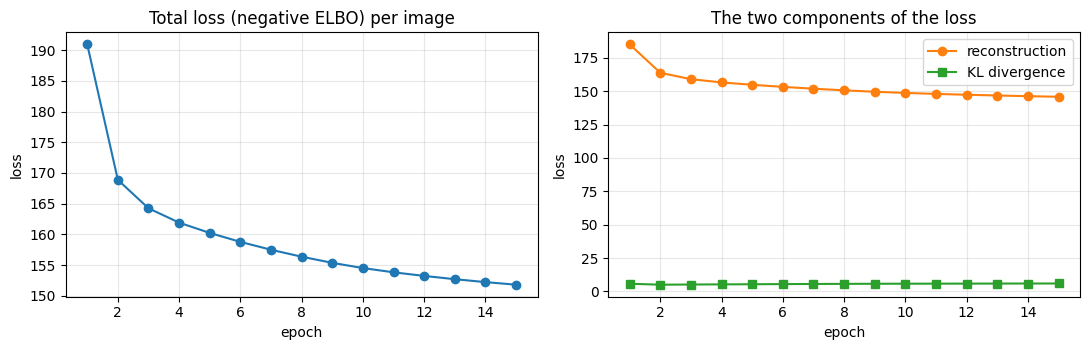

In [ ]:
# The learning curves. The total loss falls steadily; note how the reconstruction
# term dominates while the KL term settles to a small, stable value.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(range(1, epochs + 1), history["loss"], marker="o", color="#1f77b4")
ax[0].set_title("Total loss (negative ELBO) per image")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].grid(alpha=0.3)

ax[1].plot(range(1, epochs + 1), history["recon"], marker="o", label="reconstruction", color="#ff7f0e")
ax[1].plot(range(1, epochs + 1), history["kl"],    marker="s", label="KL divergence", color="#2ca02c")
ax[1].set_title("The two components of the loss")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("loss"); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Results and visualization


1. **Reconstructions**: how faithfully the model rebuilds real test digits it must pass through the 2-dimensional bottleneck.
2. **Generation**: brand-new digits produced by sampling $z \sim \mathcal{N}(0, I)$ and decoding, without any input image at all.
3. **The latent space**: where each test digit lands in the 2-dimensional space, colored by its true label.
4. **Interpolation**: walking in a straight line between two digits in latent space to see the smooth transition.

### 9.1 Reconstruction

The top row shows original test images; the bottom row shows the model's reconstruction of each. Given that all the information had to squeeze through just two numbers, the reconstructions are remarkably recognizable, though understandably a little blurry.

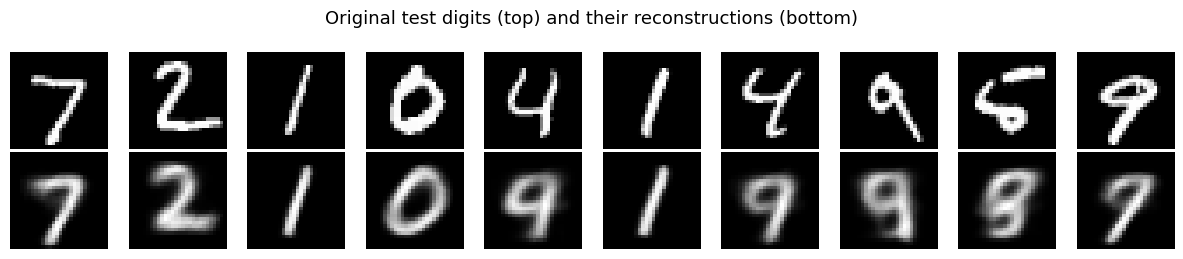

In [ ]:
model.eval()
with torch.no_grad():
    example_images, _ = next(iter(test_loader))
    example_images = example_images.to(device)
    reconstructions, _, _ = model(example_images)
    reconstructions = reconstructions.view(-1, 28, 28).cpu()

n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(12, 2.6))
for i in range(n_show):
    axes[0, i].imshow(example_images[i].squeeze().cpu(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructions[i], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("original",      fontsize=11)
axes[1, 0].set_ylabel("reconstruction", fontsize=11)
fig.suptitle("Original test digits (top) and their reconstructions (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.2 Generating Brand-New Digits

This demonstrates the generative capability of the VAE. New latent vectors are sampled directly from the prior distribution,

$$
z \sim \mathcal{N}(0, I),
$$

and then passed through the decoder to generate new images. These generated digits are **not** copies of the training data but entirely new samples produced by the model. Since the KL divergence regularizes the latent space to follow a standard normal distribution, most randomly sampled latent vectors correspond to meaningful regions of the latent space and therefore decode into realistic digit images.

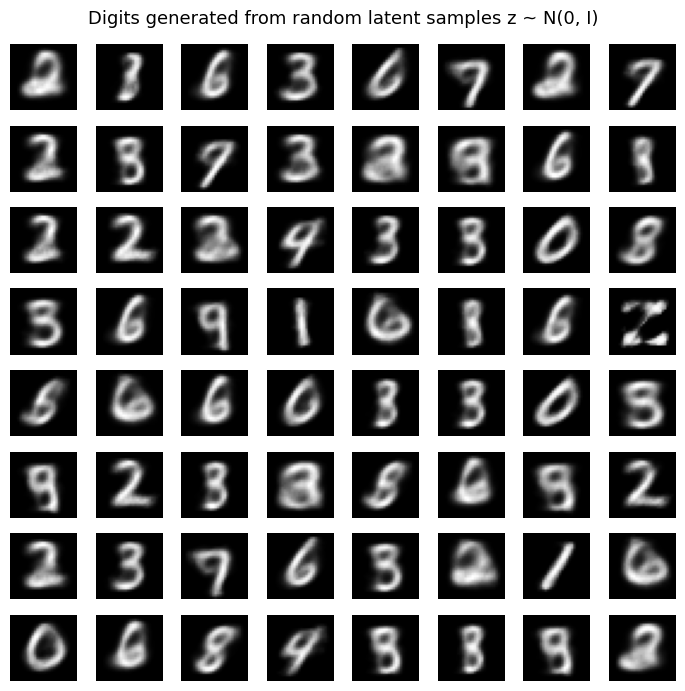

In [ ]:
with torch.no_grad():
    z_samples = torch.randn(64, model.latent_dim).to(device)   # draw from the prior
    generated = model.decode(z_samples).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(8, 8, figsize=(7, 7))
for ax, image in zip(axes.ravel(), generated):
    ax.imshow(image, cmap="gray")
    ax.axis("off")
fig.suptitle("Digits generated from random latent samples z ~ N(0, I)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.3 The Structure of the Latent Space

In this experiment, the entire test set is encoded, and each image is plotted using the mean of its latent distribution, $\mu_{\phi}(x)$. The points are colored according to their true digit labels.

Two important observations can be made. First, the latent representations form a single, continuous cluster centered near the origin, reflecting the standard normal distribution encouraged by the KL divergence term. Second, samples belonging to the same digit naturally cluster together, even though the model was trained **without using class labels**. This indicates that the VAE has learned a meaningful latent representation that captures the underlying structure of the data.

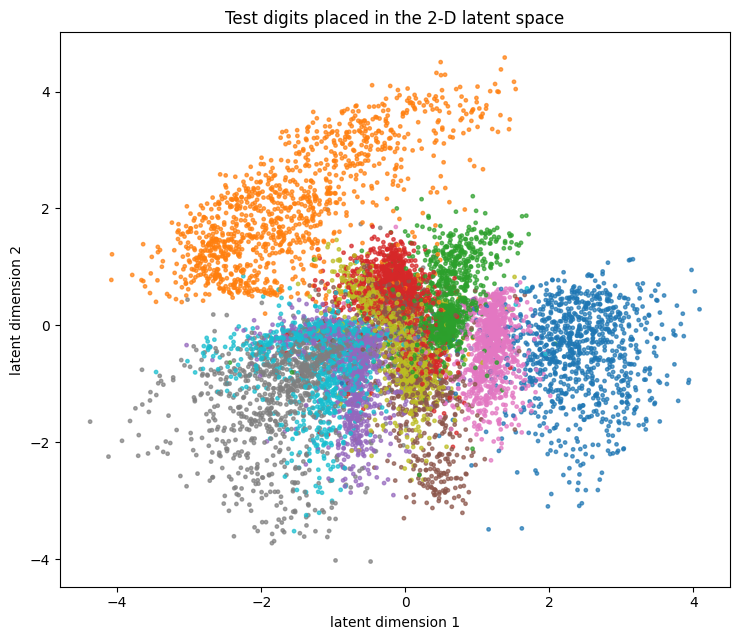

In [ ]:
all_mu, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        mu, _ = model.encode(images.to(device).view(-1, 784))
        all_mu.append(mu.cpu())
        all_labels.append(labels)
all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
scatter = ax.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels,
                     cmap="tab10", s=6, alpha=0.7)
legend = ax.legend(*scatter.legend_elements(), title="digit",
                   bbox_to_anchor=(1.01, 1), loc="upper left")
ax.add_artist(legend)
ax.set_xlabel("latent dimension 1")
ax.set_ylabel("latent dimension 2")
ax.set_title("Test digits placed in the 2-D latent space")
plt.tight_layout()
plt.show()

### 9.4 The Learned Manifold

Since the latent space is only two-dimensional, it can be visualized by placing a grid over the latent space, decoding each grid point, and displaying the resulting images. The resulting visualization is commonly referred to as the **learned manifold**.

As we move smoothly across the latent space, the generated digits also change gradually, with no abrupt transitions between neighboring points. This demonstrates that the VAE has learned a **continuous and well-structured latent space**, where nearby latent vectors correspond to similar images. In contrast, a standard autoencoder does not impose this structure, making smooth interpolation and random generation much less reliable.

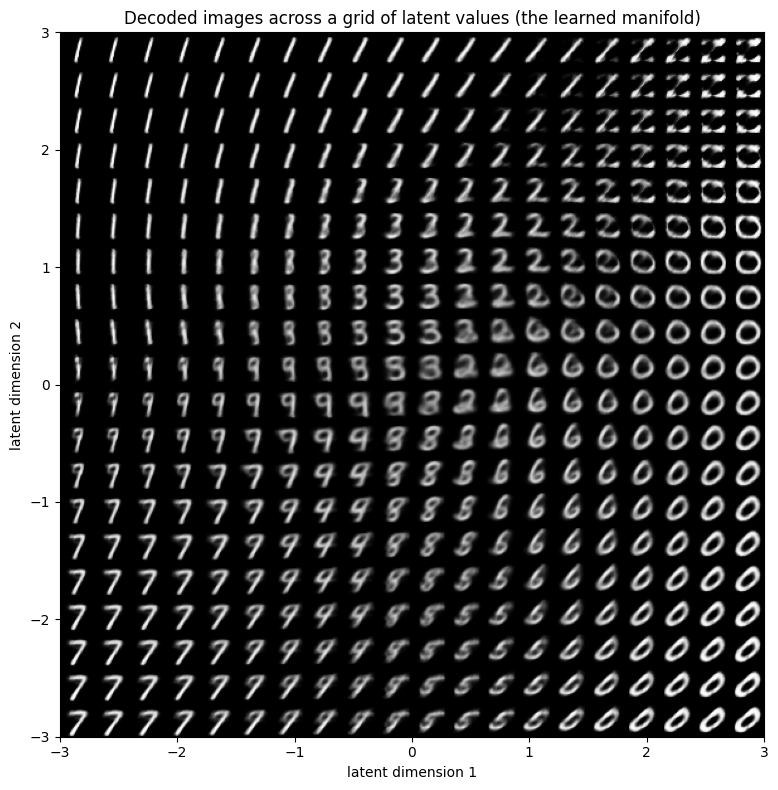

In [ ]:
grid_n = 20
grid_range = 3.0     # explore roughly +/- 3 standard deviations of the prior
grid_x = np.linspace(-grid_range, grid_range, grid_n)
grid_y = np.linspace(grid_range, -grid_range, grid_n)   # top-to-bottom

canvas = np.zeros((28 * grid_n, 28 * grid_n))
with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32, device=device)
            image = model.decode(z).view(28, 28).cpu().numpy()
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = image

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(canvas, cmap="gray", extent=[-grid_range, grid_range, -grid_range, grid_range])
ax.set_xlabel("latent dimension 1")
ax.set_ylabel("latent dimension 2")
ax.set_title("Decoded images across a grid of latent values (the learned manifold)")
plt.tight_layout()
plt.show()

### 9.5 Interpolating Between Digits

As a final demonstration, two images from the test set are encoded into their latent mean representations. A series of latent vectors is then generated by interpolating along the straight line connecting these two points, and each intermediate vector is decoded into an image.

The resulting sequence shows a smooth and realistic transition from one digit to the other. This illustrates that the VAE has learned a **continuous latent space**, where intermediate latent vectors correspond to meaningful images. In contrast, a standard autoencoder often produces unrealistic or distorted outputs when interpolating between latent representations because its latent space is not explicitly regularized.

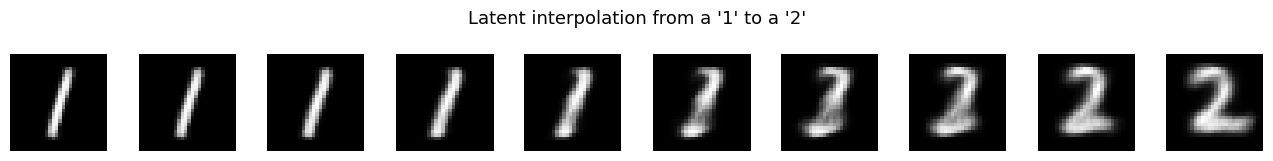

In [ ]:
def interpolate(model, img_a, img_b, steps=10):
    model.eval()
    with torch.no_grad():
        mu_a, _ = model.encode(img_a.to(device).view(1, 784))
        mu_b, _ = model.encode(img_b.to(device).view(1, 784))
        alphas = np.linspace(0, 1, steps)
        frames = []
        for a in alphas:
            z = (1 - a) * mu_a + a * mu_b
            frames.append(model.decode(z).view(28, 28).cpu().numpy())
    return frames

# Pick two test images showing different digits.
img_start, label_start = test_dataset[2]
img_end,   label_end   = test_dataset[1]

frames = interpolate(model, img_start, img_end, steps=10)

fig, axes = plt.subplots(1, len(frames), figsize=(13, 1.6))
for ax, frame in zip(axes, frames):
    ax.imshow(frame, cmap="gray")
    ax.axis("off")
fig.suptitle(f"Latent interpolation from a '{label_start}' to a '{label_end}'", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Summary and Further Reading

### What We Learned

- A standard **autoencoder** learns a compact latent representation of the input but does not impose any structure on the latent space, making it unsuitable for generating new samples.
- A **variational autoencoder (VAE)** represents each input as a **Gaussian distribution** instead of a single latent vector and introduces a **KL divergence** term that regularizes the latent space toward a standard normal distribution.
- The VAE is trained by maximizing the **Evidence Lower Bound (ELBO)**, which consists of a **reconstruction term** and a **KL divergence term**. The **reparameterization trick** enables the model to learn through the stochastic sampling process.
- In this notebook, we implemented a VAE in **PyTorch**, trained it on the **MNIST** dataset, and explored its capabilities through image reconstruction, random sample generation, latent space visualization, manifold visualization, and latent space interpolation.

### Key Formula to Remember

$$
\log p_\theta(x) \;\ge\; \mathbb{E}_{q_\phi(z\mid x)}\big[\log p_\theta(x\mid z)\big] \;-\; D_{\mathrm{KL}}\!\big(q_\phi(z\mid x)\,\|\,p(z)\big).
$$

This objective balances two goals: **accurately reconstructing the input** while **encouraging the latent representation to remain close to the standard normal distribution**.


### References

1. Kingma, D. P., and Welling, M. (2013). *Auto-Encoding Variational Bayes.* arXiv:1312.6114. The original paper that introduced the VAE and the reparameterization trick.
2. Rezende, D. J., Mohamed, S., and Wierstra, D. (2014). *Stochastic Backpropagation and Approximate Inference in Deep Generative Models.* ICML. An independent, contemporaneous derivation.
3. Doersch, C. (2016). *Tutorial on Variational Autoencoders.* arXiv:1606.05908. A widely used, gentle walk-through of the mathematics.
4. Kingma, D. P., and Welling, M. (2019). *An Introduction to Variational Autoencoders.* Foundations and Trends in Machine Learning, 12(4). A thorough modern reference.
5. Goodfellow, I., Bengio, Y., and Courville, A. (2016). *Deep Learning*, Chapter 20. MIT Press. Background on generative models.
6. LeCun, Y., Bottou, L., Bengio, Y., and Haffner, P. (1998). *Gradient-Based Learning Applied to Document Recognition.* Proceedings of the IEEE, 86(11). The source of the MNIST dataset.
7. The PyTorch VAE example, https://github.com/pytorch/examples/tree/main/vae, which inspired the reference implementation used here.